In [1]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: test.csv                
  inflating: testdata.manual.2009.06.14.csv  
  inflating: train.csv               
  inflating: training.1600000.processed.noemoticon.csv  


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



In [8]:
df = pd.read_csv("/content/testdata.manual.2009.06.14.csv", encoding='latin-1')

In [9]:
df

,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,"@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right."
0,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
1,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
2,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
3,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...
4,4,8,Mon May 11 03:22:00 UTC 2009,kindle2,GeorgeVHulme,@richardebaker no. it is too big. I'm quite ha...
...,...,...,...,...,...,...
510,4,14083,Mon May 11 03:33:38 UTC 2009,nashta,theviewfans,House Correspondents dinner was last night who...
511,4,14084,Mon May 11 05:22:12 UTC 2009,nashta,peterlikewhat,lebron and zydrunas are such an awesome duo
512,4,14085,Mon May 11 05:22:37 UTC 2009,nashta,emceet,@wordwhizkid Lebron is a beast... nobody in th...
513,4,14086,Mon May 11 05:21:45 UTC 2009,nashta,Native_011,@Pmillzz lebron IS THE BOSS


In [10]:
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

In [11]:
df

,target,id,date,flag,user,text
0,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
1,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
2,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
3,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...
4,4,8,Mon May 11 03:22:00 UTC 2009,kindle2,GeorgeVHulme,@richardebaker no. it is too big. I'm quite ha...
...,...,...,...,...,...,...
510,4,14083,Mon May 11 03:33:38 UTC 2009,nashta,theviewfans,House Correspondents dinner was last night who...
511,4,14084,Mon May 11 05:22:12 UTC 2009,nashta,peterlikewhat,lebron and zydrunas are such an awesome duo
512,4,14085,Mon May 11 05:22:37 UTC 2009,nashta,emceet,@wordwhizkid Lebron is a beast... nobody in th...
513,4,14086,Mon May 11 05:21:45 UTC 2009,nashta,Native_011,@Pmillzz lebron IS THE BOSS


In [12]:
# Convert labels (0 = negative, 4 = positive → make binary)
df['target'] = df['target'].replace(4, 1)

In [13]:
df

,target,id,date,flag,user,text
0,1,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
1,1,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
2,1,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
3,1,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...
4,1,8,Mon May 11 03:22:00 UTC 2009,kindle2,GeorgeVHulme,@richardebaker no. it is too big. I'm quite ha...
...,...,...,...,...,...,...
510,1,14083,Mon May 11 03:33:38 UTC 2009,nashta,theviewfans,House Correspondents dinner was last night who...
511,1,14084,Mon May 11 05:22:12 UTC 2009,nashta,peterlikewhat,lebron and zydrunas are such an awesome duo
512,1,14085,Mon May 11 05:22:37 UTC 2009,nashta,emceet,@wordwhizkid Lebron is a beast... nobody in th...
513,1,14086,Mon May 11 05:21:45 UTC 2009,nashta,Native_011,@Pmillzz lebron IS THE BOSS


In [14]:
# Clean text
def clean_text(text):
    text = re.sub(r'@\w+', '', text)  # remove @user
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^A-Za-z\s]', '', text)  # remove special chars
    text = text.lower()
    return text

df['text'] = df['text'].apply(clean_text)

In [15]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

In [16]:
sequences = tokenizer.texts_to_sequences(df['text'])

In [17]:
# Padding
X = pad_sequences(sequences, maxlen=100)
y = df['target']

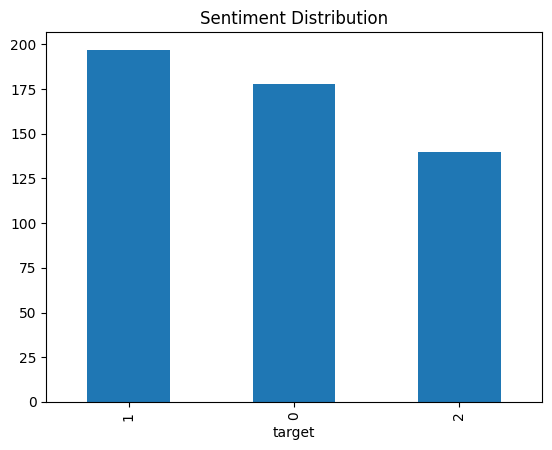

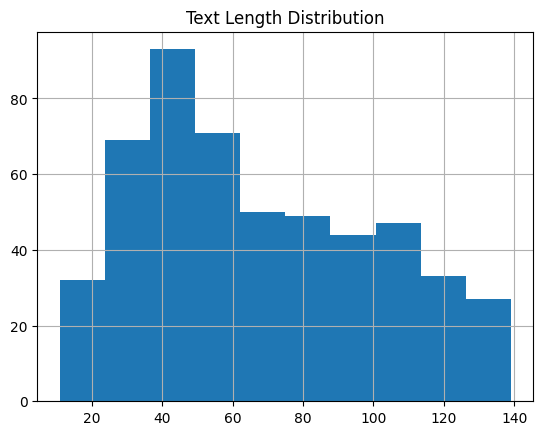

In [18]:
import matplotlib.pyplot as plt

# Class distribution
df['target'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

# Text length
df['length'] = df['text'].apply(len)
df['length'].hist()
plt.title("Text Length Distribution")
plt.show()

In [20]:
df.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0
length,0


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.3762 - loss: 0.5866 - val_accuracy: 0.4078 - val_loss: 0.3399
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.3762 - loss: 0.1964 - val_accuracy: 0.4078 - val_loss: 0.1815
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.3762 - loss: 0.1097 - val_accuracy: 0.4078 - val_loss: 0.0226
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.4175 - loss: -0.0701 - val_accuracy: 0.4272 - val_loss: -0.0893
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.4369 - loss: -0.2069 - val_accuracy: 0.4272 - val_loss: -0.1749


In [28]:
# Predict
predictions = model.predict(X_test)

# Convert probabilities → 0 or 1
predictions = (predictions > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step


In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.42718446601941745


In [30]:
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100)
    pred = model.predict(padded)

    if pred > 0.5:
        return "Positive 😊"
    else:
        return "Negative 😞"

print(predict_sentiment("I love this product"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
Positive 😊
